In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


In [17]:
df=pd.read_csv(r"C:\Users\Dell\Documents\My ML Projects\Customer churn project\data\Telco_customer_churn.csv")

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [19]:
df.shape

(7043, 33)

In [20]:
df.head(5)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [21]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [22]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


In [23]:
drop_cols=['CustomerID','Count','Country','State','City','Zip Code','Lat Long','Latitude','Longitude','Churn Reason']
df=df.drop(columns=drop_cols)

In [27]:
df.shape

(7043, 23)

In [26]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   str    
 1   Senior Citizen     7043 non-null   str    
 2   Partner            7043 non-null   str    
 3   Dependents         7043 non-null   str    
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   str    
 6   Multiple Lines     7043 non-null   str    
 7   Internet Service   7043 non-null   str    
 8   Online Security    7043 non-null   str    
 9   Online Backup      7043 non-null   str    
 10  Device Protection  7043 non-null   str    
 11  Tech Support       7043 non-null   str    
 12  Streaming TV       7043 non-null   str    
 13  Streaming Movies   7043 non-null   str    
 14  Contract           7043 non-null   str    
 15  Paperless Billing  7043 non-null   str    
 16  Payment Method     7043 non-null   

In [29]:
df['Total Charges'].head(10)

0     108.15
1     151.65
2      820.5
3    3046.05
4     5036.3
5     528.35
6      39.65
7      20.15
8    4749.15
9       30.2
Name: Total Charges, dtype: str

Handling Missing Values

The column contained numeric values but also had empty strings, so pandas inferred it as object type. I converted it using pd.to_numeric() with errors='coerce' and handled the resulting missing values."

In [30]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'],errors='coerce')

In [31]:
df.isnull().sum()

Gender                0
Senior Citizen        0
Partner               0
Dependents            0
Tenure Months         0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges        11
Churn Label           0
Churn Value           0
Churn Score           0
CLTV                  0
dtype: int64

In [32]:
df=df.dropna()

In [33]:
df.isnull().sum()

Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
Churn Score          0
CLTV                 0
dtype: int64

In [34]:
df.shape

(7032, 23)

In [35]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include='object').columns


C:\Users\Dell\AppData\Local\Temp\ipykernel_10252\915213741.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [36]:
num_cols

Index(['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'Churn Score', 'CLTV'],
      dtype='str')

In [37]:
cat_cols

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Churn Label'],
      dtype='str')

In [42]:
num_cols=['Tenure Months', 'Monthly Charges', 'Total Charges']
num_cols

['Tenure Months', 'Monthly Charges', 'Total Charges']

**Numerical Features Distribution**

1.Tenure Months

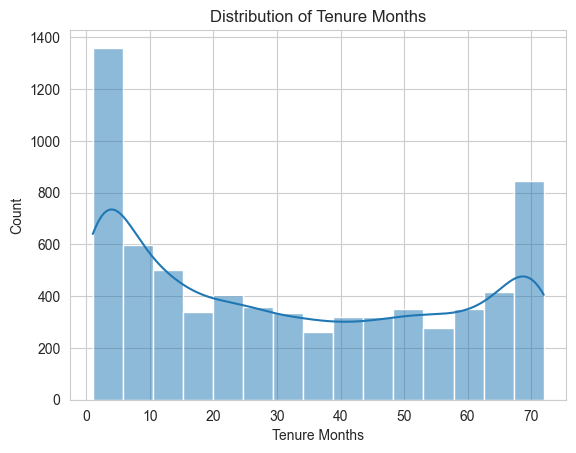

In [43]:
sns.histplot(df['Tenure Months'],kde=True)
plt.title("Distribution of Tenure Months")
plt.show()

There are two types of customers:

New customers (low tenure)

Long-term loyal customers (high tenure)

"Tenure shows a bimodal distribution indicating a mix of new and long-term customers, which suggests customer retention behavior is significant in this dataset."

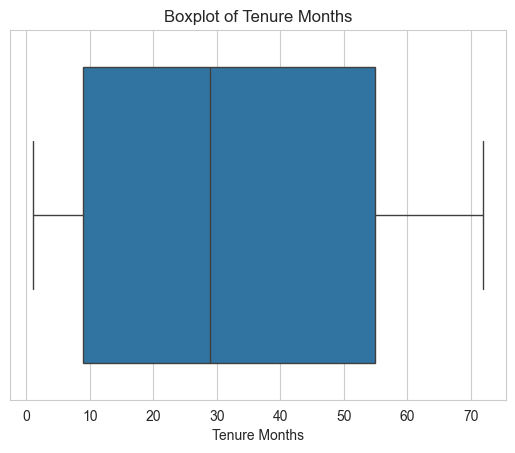

In [44]:
sns.boxplot(x=df['Tenure Months'])
plt.title("Boxplot of Tenure Months")
plt.show()

2.Monthly Charges

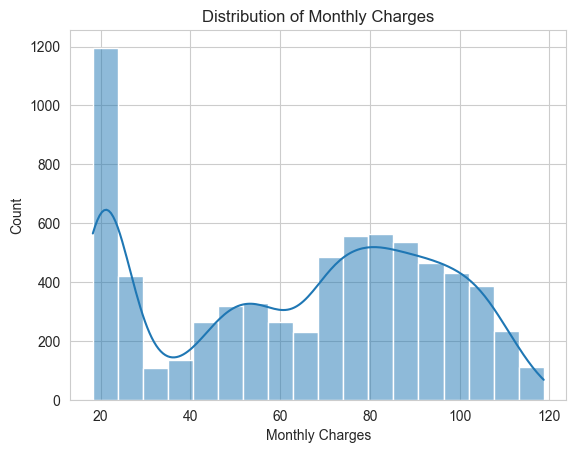

In [45]:
sns.histplot(df['Monthly Charges'],kde=True)
plt.title("Distribution of Monthly Charges")
plt.show()

Customers are distributed across different pricing tiers, possibly due to different service plans

Monthly charges show a multi-modal distribution, indicating customers are segmented into different pricing plans.

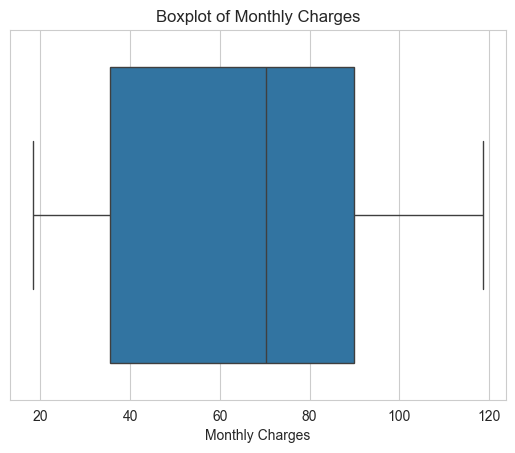

In [46]:
sns.boxplot(x=df['Monthly Charges'])
plt.title("Boxplot of Monthly Charges")
plt.show()

3.Total Charges

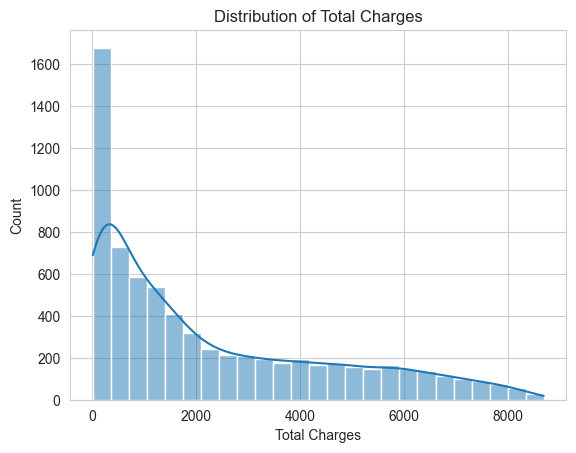

In [47]:
sns.histplot(df['Total Charges'],kde=True)
plt.title("Distribution of Total Charges")
plt.show()

Total charges is right-skewed, indicating most customers have lower accumulated charges, likely due to shorter tenure

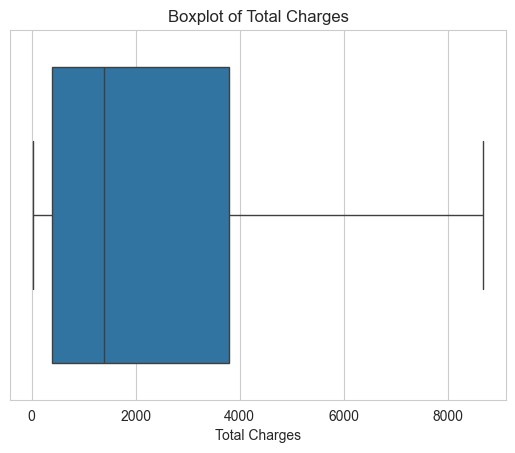

In [48]:
sns.boxplot(x=df['Total Charges'])
plt.title("Boxplot of Total Charges")
plt.show()

"Most customers have low total charges, with a few high-value customers, which results in a right-skewed distribution."

**Catogorical features Distribution**

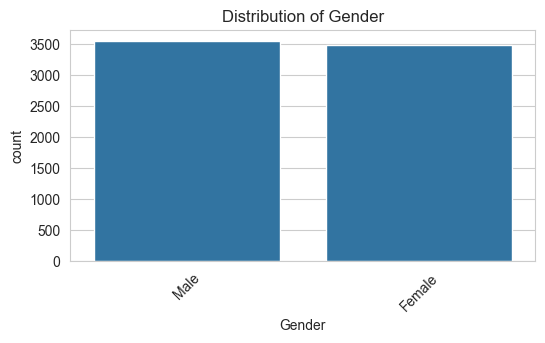

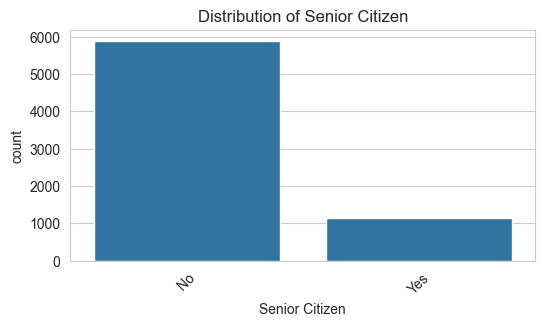

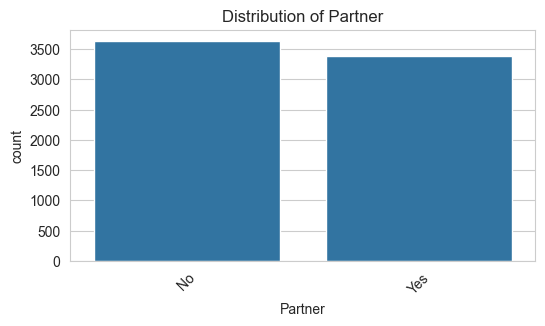

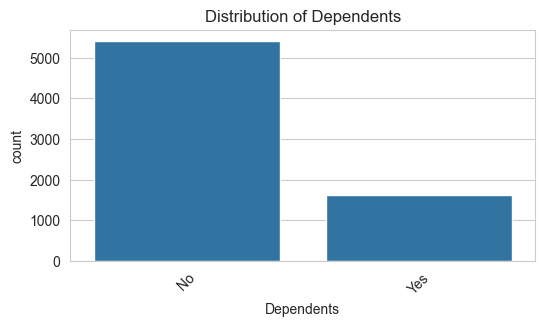

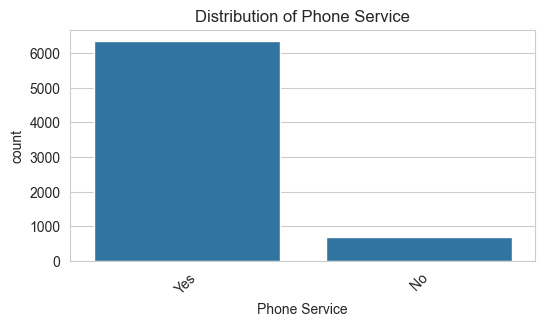

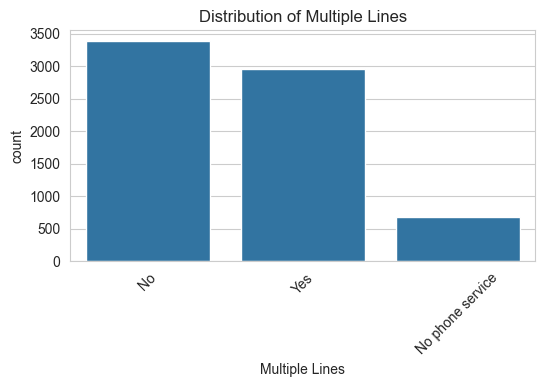

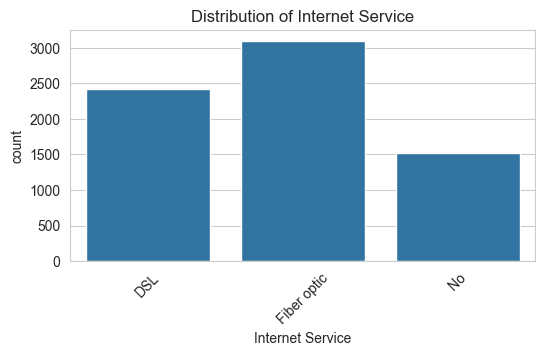

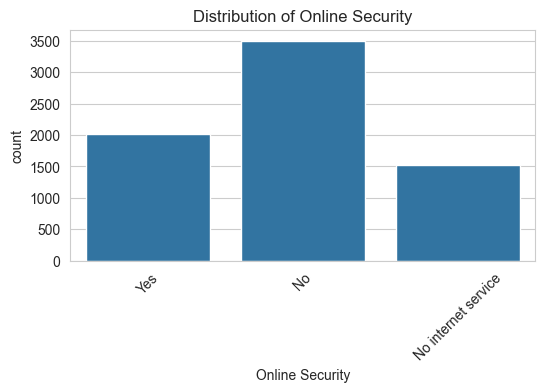

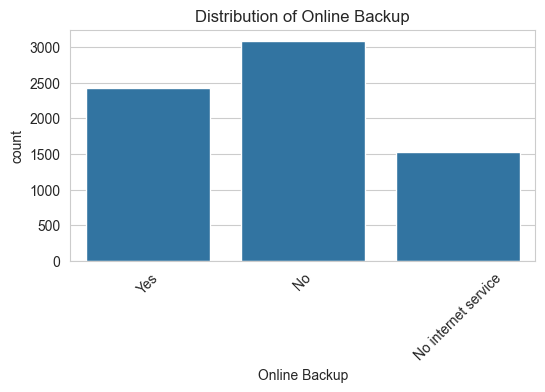

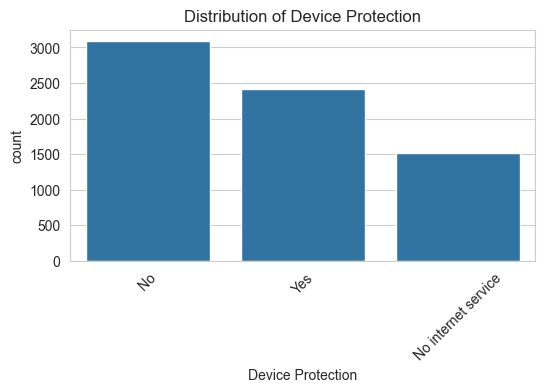

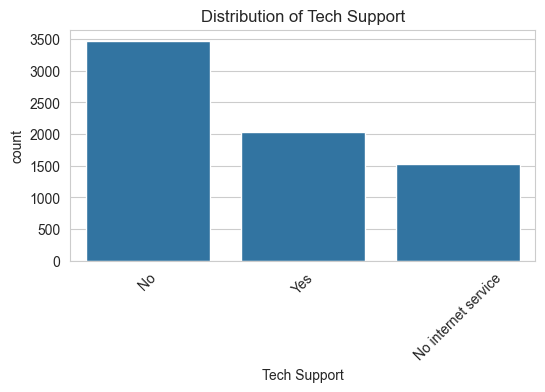

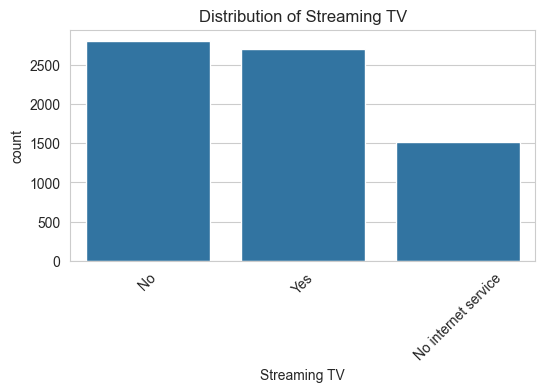

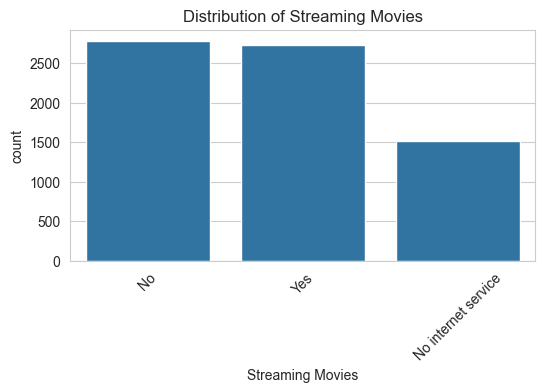

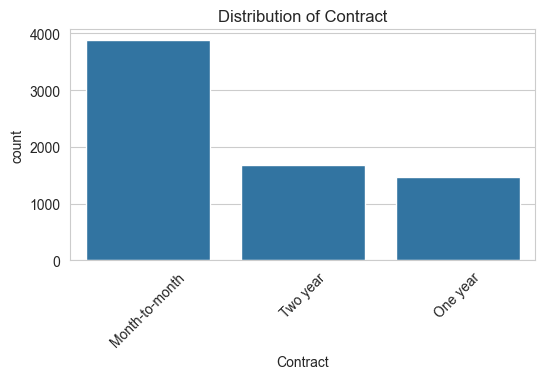

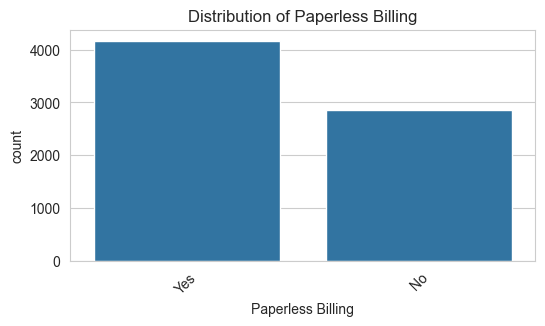

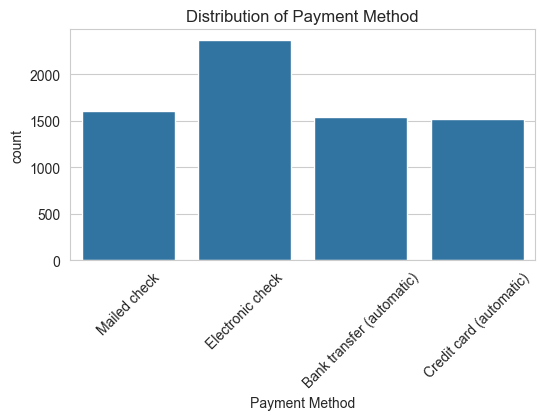

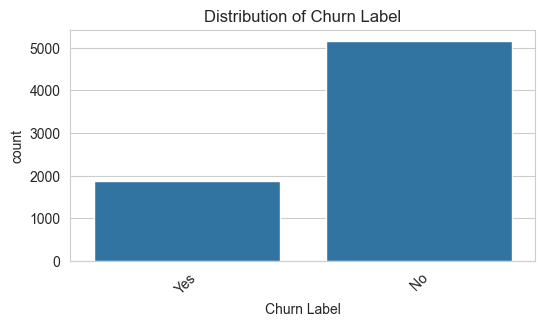

In [49]:
for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col,data=df)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}")
    plt.show()

Most customers use electronic check as their payment method, while other methods are more evenly distributed.

Fiber optic is the most commonly used internet service, followed by DSL, while fewer customers have no internet service

"Most customers prefer month-to-month contracts, while fewer customers opt for long-term contracts like 1-year and 2-year plans

**Target variable and its relationship with other features**


In [50]:
#Define Target Variable
target = 'Churn Value'

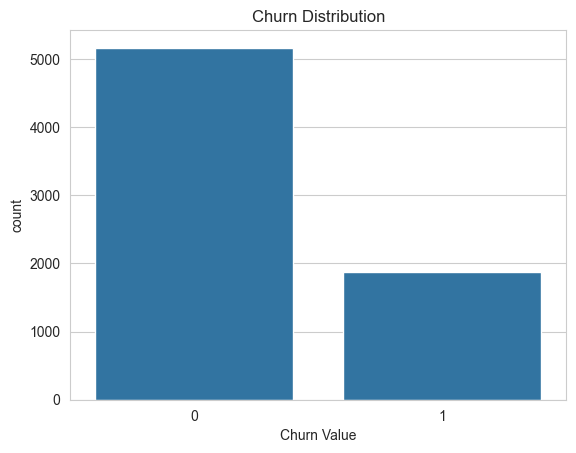

In [51]:
#Target Distribution
sns.countplot(x='Churn Value',data=df)
plt.title("Churn Distribution")
plt.show()

The dataset is imbalanced with significantly more non-churned customers than churned customers, which needs to be considered during model evaluation

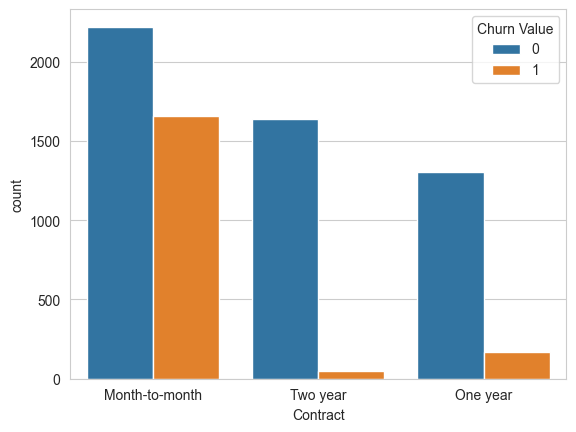

In [52]:
# Contract vs Churn Value
sns.countplot(x='Contract',hue='Churn Value',data=df)
plt.show()

Customers on month-to-month contracts show significantly higher churn compared to 1-year and 2-year contracts. This indicates that long-term contracts improve customer retention and reduce churn.

**Contract type is one of the strongest predictors of churn.**

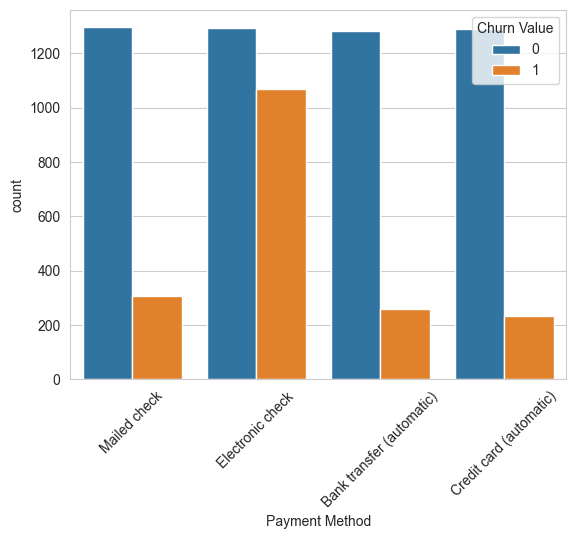

In [53]:
# Payment method vs Churn Value
sns.countplot(x='Payment Method', hue='Churn Value', data=df)
plt.xticks(rotation=45)
plt.show()

Customers using electronic check as payment method have higher churn compared to other methods like credit card or bank transfer

Customers who use electronic check show higher churn, possibly due to lack of automated payment systems, which may lead to inconvenience or missed payments, increasing the likelihood of churn

Auto-payment → smooth experience 

Manual payment (electronic check) → friction

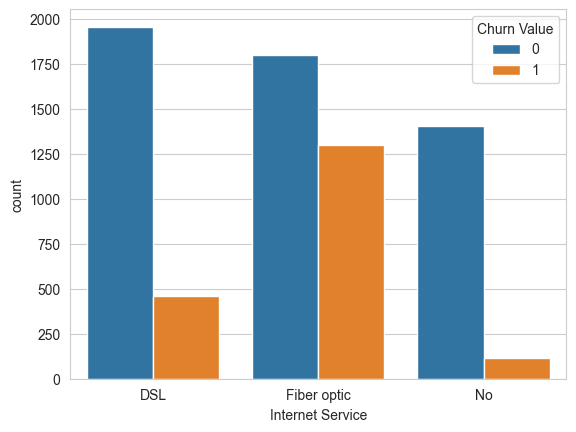

In [54]:
#Internet Services vs Churn Value
sns.countplot(x='Internet Service', hue='Churn Value', data=df)
plt.show()

Customers using fiber optic internet service have higher churn compared to DSL and those without internet service

Customers using fiber optic services show higher churn compared to DSL users. This may be due to higher pricing or dissatisfaction with service quality, making them more likely to leave.

Possible reasons:

Fiber → expensive 

Higher expectations → more dissatisfaction 

More alternatives → easier switching


Customers with month-to-month contracts show significantly higher churn

Customers using electronic check have higher churn rates

Fiber optic users are more likely to churn compared to DSL users

Customers with lower tenure tend to churn more

The dataset is imbalanced, with more non-churned customers

**Enocding Categorical Features**(Model cannot understand text data)

In [55]:
cat_cols

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Churn Label'],
      dtype='str')

In [59]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340


In [60]:
#Removing unneccessary target column 'Churn Label' which is duplicate of 'Churn Value' which is already a target feature
df=df.drop(columns=['Churn Label'])


In [63]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7032 non-null   str    
 1   Senior Citizen     7032 non-null   str    
 2   Partner            7032 non-null   str    
 3   Dependents         7032 non-null   str    
 4   Tenure Months      7032 non-null   int64  
 5   Phone Service      7032 non-null   str    
 6   Multiple Lines     7032 non-null   str    
 7   Internet Service   7032 non-null   str    
 8   Online Security    7032 non-null   str    
 9   Online Backup      7032 non-null   str    
 10  Device Protection  7032 non-null   str    
 11  Tech Support       7032 non-null   str    
 12  Streaming TV       7032 non-null   str    
 13  Streaming Movies   7032 non-null   str    
 14  Contract           7032 non-null   str    
 15  Paperless Billing  7032 non-null   str    
 16  Payment Method     7032 non-null   str  

In [64]:
df = df.drop(columns=['Churn Score', 'CLTV'])

In [65]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7032 non-null   str    
 1   Senior Citizen     7032 non-null   str    
 2   Partner            7032 non-null   str    
 3   Dependents         7032 non-null   str    
 4   Tenure Months      7032 non-null   int64  
 5   Phone Service      7032 non-null   str    
 6   Multiple Lines     7032 non-null   str    
 7   Internet Service   7032 non-null   str    
 8   Online Security    7032 non-null   str    
 9   Online Backup      7032 non-null   str    
 10  Device Protection  7032 non-null   str    
 11  Tech Support       7032 non-null   str    
 12  Streaming TV       7032 non-null   str    
 13  Streaming Movies   7032 non-null   str    
 14  Contract           7032 non-null   str    
 15  Paperless Billing  7032 non-null   str    
 16  Payment Method     7032 non-null   str  

In [66]:
#Handling simple binary columns
binary_cols=['Partner','Dependents','Phone Service','Paperless Billing']


In [67]:
#Encode them
for col in binary_cols:
    df[col] = df[col].map({'Yes':1,'No':0})
    

In [72]:
df['Dependents'].head()

0    0
1    1
2    1
3    1
4    1
Name: Dependents, dtype: int64

In [73]:
#Special Binary Column
#Gender
df['Gender'] = df['Gender'].map({'Male':1,'Female':0})


In [74]:
df['Gender'].head()

0    1
1    0
2    0
3    0
4    1
Name: Gender, dtype: int64

In [75]:
#Senior Citizen

df['Senior Citizen'].value_counts()

Senior Citizen
No     5890
Yes    1142
Name: count, dtype: int64

In [76]:
df['Senior Citizen'] = df['Senior Citizen'].map({'Yes': 1, 'No': 0})

In [77]:
df['Senior Citizen'].value_counts()

Senior Citizen
0    5890
1    1142
Name: count, dtype: int64

In [78]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7032 non-null   int64  
 1   Senior Citizen     7032 non-null   int64  
 2   Partner            7032 non-null   int64  
 3   Dependents         7032 non-null   int64  
 4   Tenure Months      7032 non-null   int64  
 5   Phone Service      7032 non-null   int64  
 6   Multiple Lines     7032 non-null   str    
 7   Internet Service   7032 non-null   str    
 8   Online Security    7032 non-null   str    
 9   Online Backup      7032 non-null   str    
 10  Device Protection  7032 non-null   str    
 11  Tech Support       7032 non-null   str    
 12  Streaming TV       7032 non-null   str    
 13  Streaming Movies   7032 non-null   str    
 14  Contract           7032 non-null   str    
 15  Paperless Billing  7032 non-null   int64  
 16  Payment Method     7032 non-null   str  

In [80]:
df.head(20)

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
1,0,0,0,1,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1
2,0,0,0,1,8,1,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,99.65,820.50,1
3,0,0,1,1,28,1,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,1,Electronic check,104.80,3046.05,1
4,1,0,0,1,49,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Bank transfer (automatic),103.70,5036.30,1
5,0,0,1,0,10,1,No,DSL,No,No,Yes,Yes,No,No,Month-to-month,0,Credit card (automatic),55.20,528.35,1
6,1,1,0,0,1,0,No phone service,DSL,No,No,Yes,No,No,Yes,Month-to-month,1,Electronic check,39.65,39.65,1
7,1,0,0,0,1,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,0,Mailed check,20.15,20.15,1
8,1,0,1,1,47,1,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,1,Electronic check,99.35,4749.15,1
9,1,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,0,Electronic check,30.20,30.20,1


**Handle “No internet service” columns**

In [81]:
multi_binary_cols = ['Multiple Lines','Online Security','Online Backup','Device Protection','Tech Support','Streaming TV','Streaming Movies']

They contain values like:

Yes
No
"No internet service" / "No phone service"

Model cannot handle this directly

In [82]:
#Convert to simple Yes/No
for col in multi_binary_cols:
    df[col] = df[col].replace({
        'No internet service':'No',
        'No phone service':'No'
    })

In [83]:
for col in multi_binary_cols:
    df[col] = df[col].map({'Yes':1,'No':0})

In [86]:
df['Multiple Lines'].value_counts()

Multiple Lines
0    4065
1    2967
Name: count, dtype: int64

**Next Remaining Columns**

1.Internet Service

2.Contract

3.Payment Method


**One Hot Encoding for these Columns**

In [87]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7032 non-null   int64  
 1   Senior Citizen     7032 non-null   int64  
 2   Partner            7032 non-null   int64  
 3   Dependents         7032 non-null   int64  
 4   Tenure Months      7032 non-null   int64  
 5   Phone Service      7032 non-null   int64  
 6   Multiple Lines     7032 non-null   int64  
 7   Internet Service   7032 non-null   str    
 8   Online Security    7032 non-null   int64  
 9   Online Backup      7032 non-null   int64  
 10  Device Protection  7032 non-null   int64  
 11  Tech Support       7032 non-null   int64  
 12  Streaming TV       7032 non-null   int64  
 13  Streaming Movies   7032 non-null   int64  
 14  Contract           7032 non-null   str    
 15  Paperless Billing  7032 non-null   int64  
 16  Payment Method     7032 non-null   str  

In [89]:
#df = pd.get_dummies(df,columns=['Internet Service','Contract','Payment method'], drop_first=True)
df = pd.get_dummies(df, columns=[
    'Internet Service', 'Contract', 'Payment Method'
], drop_first=True)

In [90]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Gender                                  7032 non-null   int64  
 1   Senior Citizen                          7032 non-null   int64  
 2   Partner                                 7032 non-null   int64  
 3   Dependents                              7032 non-null   int64  
 4   Tenure Months                           7032 non-null   int64  
 5   Phone Service                           7032 non-null   int64  
 6   Multiple Lines                          7032 non-null   int64  
 7   Online Security                         7032 non-null   int64  
 8   Online Backup                           7032 non-null   int64  
 9   Device Protection                       7032 non-null   int64  
 10  Tech Support                            7032 non-null   int64  
 11  Streami

In [91]:
#convert bool columns to int
bool_cols = df.select_dtypes(include='bool').columns

for col in bool_cols:
    df[col] = df[col].astype(int)

In [92]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Gender                                  7032 non-null   int64  
 1   Senior Citizen                          7032 non-null   int64  
 2   Partner                                 7032 non-null   int64  
 3   Dependents                              7032 non-null   int64  
 4   Tenure Months                           7032 non-null   int64  
 5   Phone Service                           7032 non-null   int64  
 6   Multiple Lines                          7032 non-null   int64  
 7   Online Security                         7032 non-null   int64  
 8   Online Backup                           7032 non-null   int64  
 9   Device Protection                       7032 non-null   int64  
 10  Tech Support                            7032 non-null   int64  
 11  Streami